# 03 · An Optimisation Problem to Solve: MLE and MAP

*Companion notebook for the chapter sections* **An Optimization Problem to Solve · Maximum Likelihood Estimation · Maximum A Posteriori Estimation**

Training an ordinary network *is* a statistical estimation problem. This notebook shows that

* minimising squared error  = **Maximum Likelihood Estimation (MLE)** with Gaussian noise,
* adding weight decay (L2) = **Maximum A Posteriori (MAP)** estimation with a Gaussian prior,

and why both still give only **one** set of weights.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(3)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. The model

We use a model that is linear in its weights, with polynomial features $\boldsymbol\phi(x)=(1,x,x^2,\dots,x^9)$:

$$y=\mathbf w^\top\boldsymbol\phi(x)+\varepsilon,\qquad \varepsilon\sim\mathcal N(0,\sigma^2).$$

Ten weights and only twelve data points: a recipe for over-fitting — just like a big neural network on a small data set.

In [2]:
f = lambda x: np.sin(2 * np.pi * x)
n, sigma = 12, 0.2
x = np.sort(rng.uniform(0, 1, n)); y = f(x) + sigma * rng.standard_normal(n)
xg = np.linspace(0, 1, 300)

deg = 9
Phi  = lambda x: np.vander(x, deg + 1, increasing=True)
P, Pg = Phi(x), Phi(xg)

## 2. Maximum Likelihood Estimation

The likelihood of the data is $p(\mathbf y\mid\mathbf w)=\prod_i\mathcal N(y_i\mid\mathbf w^\top\boldsymbol\phi_i,\sigma^2)$, so the negative log-likelihood is

$$-\log p(\mathbf y\mid\mathbf w)=\frac1{2\sigma^2}\sum_i\big(y_i-\mathbf w^\top\boldsymbol\phi_i\big)^2+\text{const}.$$

**Maximising the likelihood = minimising the sum of squared errors.** The solution is $\mathbf w_{\text{MLE}}=(\Phi^\top\Phi)^{-1}\Phi^\top\mathbf y$.

In [3]:
w_mle = np.linalg.lstsq(P, y, rcond=None)[0]
np.set_printoptions(suppress=True)
print("MLE weights:", np.round(w_mle, 1))   # huge, alternating-sign weights: a symptom of over-fitting

MLE weights: [      -5.       279.3    -5513.8    55250.7  -312473.8  1057332.2
 -2181537.1  2684205.  -1806312.1   510741.8]


## 3. Maximum A Posteriori

Add a Gaussian **prior** on the weights, $p(\mathbf w)=\mathcal N(\mathbf 0,\tau^2 I)$. Bayes' rule gives $\log p(\mathbf w\mid\mathbf y)=\log p(\mathbf y\mid\mathbf w)+\log p(\mathbf w)+\text{const}$, so

$$-\log p(\mathbf w\mid\mathbf y)=\frac1{2\sigma^2}\sum_i\big(y_i-\mathbf w^\top\boldsymbol\phi_i\big)^2+\frac1{2\tau^2}\lVert\mathbf w\rVert^2+\text{const}.$$

That is **ridge regression / weight decay** with $\lambda=\sigma^2/\tau^2$:

$$\mathbf w_{\text{MAP}}=(\Phi^\top\Phi+\lambda I)^{-1}\Phi^\top\mathbf y .$$

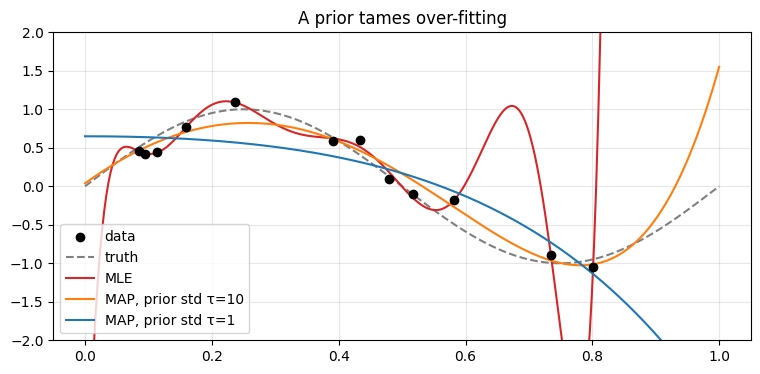

In [4]:
def w_map(tau):
    lam = sigma**2 / tau**2
    return np.linalg.solve(P.T @ P + lam * np.eye(deg + 1), P.T @ y)

plt.scatter(x, y, c="k", zorder=3, label="data")
plt.plot(xg, f(xg), "--", c="gray", label="truth")
plt.plot(xg, Pg @ w_mle, c="C3", label="MLE")
for tau, c in [(10, "C1"), (1, "C0")]:
    plt.plot(xg, Pg @ w_map(tau), c=c, label=f"MAP, prior std τ={tau}")
plt.ylim(-2, 2); plt.legend(); plt.title("A prior tames over-fitting"); plt.show()

### Check: the closed form equals direct optimisation of the log-posterior
This is how a neural network is actually trained — by numerically minimising the negative log-posterior.

In [5]:
tau = 1.0
def neg_log_post(w):
    return np.sum((y - P @ w) ** 2) / (2 * sigma**2) + np.sum(w**2) / (2 * tau**2)

w_opt = minimize(neg_log_post, np.zeros(deg + 1), method="L-BFGS-B").x
print("closed-form MAP :", np.round(w_map(tau), 3))
print("numerical MAP   :", np.round(w_opt, 3))
print("max difference  :", np.abs(w_map(tau) - w_opt).max())

closed-form MAP : [ 0.649  0.002 -1.144 -1.063 -0.716 -0.418 -0.215 -0.089 -0.015  0.025]
numerical MAP   : [ 0.649  0.002 -1.144 -1.063 -0.716 -0.418 -0.215 -0.089 -0.015  0.025]
max difference  : 1.5740469506699342e-05


## 4. What point estimates cannot tell you

MLE and MAP both return the **single most probable** weight vector — the peak of a distribution. They throw away its **width**.
Let's look at the posterior over just two weights ($w_0,w_1$ of a straight-line model) to see what is lost.

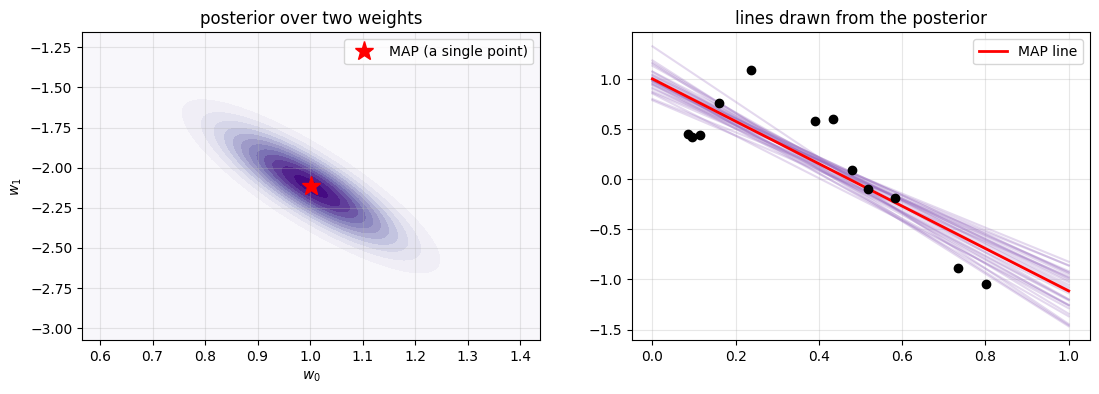

In [6]:
P2 = np.vander(x, 2, increasing=True)
tau2 = 2.0
A = P2.T @ P2 / sigma**2 + np.eye(2) / tau2**2          # posterior precision
S = np.linalg.inv(A); m = S @ P2.T @ y / sigma**2        # posterior covariance and mean (see notebook 04)

sd0, sd1 = np.sqrt(np.diag(S))
w0, w1 = np.meshgrid(np.linspace(m[0] - 4 * sd0, m[0] + 4 * sd0, 200), np.linspace(m[1] - 4 * sd1, m[1] + 4 * sd1, 200))
W = np.stack([w0 - m[0], w1 - m[1]], -1)
dens = np.exp(-0.5 * np.einsum("...i,ij,...j", W, A, W))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].contourf(w0, w1, dens, levels=15, cmap="Purples")
ax[0].plot(*m, "r*", ms=14, label="MAP (a single point)")
ax[0].set_xlabel("$w_0$"); ax[0].set_ylabel("$w_1$"); ax[0].legend(); ax[0].set_title("posterior over two weights")

samples = rng.multivariate_normal(m, S, 30)
for s in samples:
    ax[1].plot(xg, s[0] + s[1] * xg, c="C4", alpha=0.25)
ax[1].plot(xg, m[0] + m[1] * xg, c="r", lw=2, label="MAP line")
ax[1].scatter(x, y, c="k", zorder=3); ax[1].legend(); ax[1].set_title("lines drawn from the posterior")
plt.show()

Every line on the right is consistent with the data. The Bayesian approach keeps **all of them**, weighted by the posterior. MAP keeps only the red one.

## Summary

| method | objective | result |
|---|---|---|
| MLE | $\max_{\mathbf w} p(\mathcal D\mid\mathbf w)$ | one weight vector; over-fits small data |
| MAP | $\max_{\mathbf w} p(\mathcal D\mid\mathbf w)p(\mathbf w)$ | one weight vector; regularised |
| **Bayesian** | $p(\mathbf w\mid\mathcal D)$ — the whole distribution | uncertainty over weights *and* predictions |

## Exercises
1. Use a Laplace prior $p(w)\propto e^{-|w|/b}$. Which familiar penalty do you get? Minimise it with `scipy.optimize.minimize`.
2. Plot the test error of MAP as a function of $\tau$ on a log scale. Which $\tau$ is best?
3. Why does MAP depend on how you *parametrise* the weights while the full posterior predictive does not?